# Laboratorio 2 Regresion Lineal Multiple
## Lora Gallardo Rolando

## Contexto del dataset:
En este trabajo se utiliza el dataset Apartments for Rent Classified, que contiene información de aproximadamente 100 mil anuncios de propiedades en alquiler en Estados Unidos. El objetivo es desarrollar un modelo de regresión lineal múltiple capaz de estimar el precio de alquiler de una propiedad (price) utilizando múltiples características relacionadas con sus dimensiones, ubicación, servicios y demás atributos disponibles. Debido a que el dataset contiene variables numéricas, categóricas y textuales, se realizó un proceso de preprocesamiento utilizando Pandas, mediante el cual se transformaron estas variables a un formato numérico adecuado para el entrenamiento del modelo.

# Librerias usadas

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Carga del dataset desde nuestro gdrive

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab/datasets/apartments_for_rent_classified_100K.csv",sep=";",
    encoding="latin1")

/tmp/ipykernel_6810/3424682557.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Colab/datasets/apartments_for_rent_classified_100K.csv",sep=";",


## Estructura del dataset

y = price, en nuestro dataset esta representado como una caracterisitica pero nosotros lo tomaremos como una etiqueta

In [3]:
print("\nColumnas:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

print("\nForma del dataset:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nValores nulos totales:")
print(df.isnull().sum().sum())


Columnas:
0 -> id
1 -> category
2 -> title
3 -> body
4 -> amenities
5 -> bathrooms
6 -> bedrooms
7 -> currency
8 -> fee
9 -> has_photo
10 -> pets_allowed
11 -> price
12 -> price_display
13 -> price_type
14 -> square_feet
15 -> address
16 -> cityname
17 -> state
18 -> latitude
19 -> longitude
20 -> source
21 -> time

Forma del dataset:
(99492, 22)

Tipos de datos:
id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price            float64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

Valores nulos por columna:
id                   0
category          

In [4]:
df = df.dropna(subset=["price"]).copy()

print("Filas después de eliminar precios nulos:", len(df))

Filas después de eliminar precios nulos: 99491


## Preparacion de los datos
Eliminado nulos, eliminado columnas que no seran utiles para infererir

In [5]:
# Convertir timestamp Unix a fecha
df["datetime"] = pd.to_datetime(df["time"], unit="s")

# Crear características temporales
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["day_of_week"] = df["datetime"].dt.dayofweek
df["hour"] = df["datetime"].dt.hour

# Eliminar las columnas originales
df.drop(columns=["time", "datetime"], inplace=True)

# Longitud del título
df["title_length"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.len()
)

# Cantidad de palabras del título
df["title_words"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

# Longitud de la descripción
df["body_length"] = (
    df["body"]
    .fillna("")
    .astype(str)
    .str.len()
)

# Cantidad de palabras
df["body_words"] = (
    df["body"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

In [6]:
df["amenities_count"] = (
    df["amenities"]
    .fillna("")
    .astype(str)
    .apply(
        lambda x: 0 if x.strip() == "" else len(x.split(","))
    )
)

In [7]:
amenities_features = [
    "Dishwasher",
    "Parking",
    "Pool",
    "Gym",
    "Fireplace",
    "Storage",
    "Wood Floors",
    "Gated",
    "Refrigerator",
    "Elevator",
    "Patio/Deck",
    "Clubhouse",
    "Cable or Satellite",
    "Garbage Disposal"
]

In [8]:
for amenity in amenities_features:

    nombre_columna = (
        "has_"
        + amenity.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    df[nombre_columna] = (
        df["amenities"]
        .fillna("")
        .str.contains(
            amenity,
            case=False,
            regex=False
        )
        .astype(int)
    )

In [9]:
df["fee"] = df["fee"].map({
    "No": 0,
    "Yes": 1
})

In [10]:
df["photo_yes"] = (
    df["has_photo"] == "Yes"
).astype(int)

df["photo_thumbnail"] = (
    df["has_photo"] == "Thumbnail"
).astype(int)

In [11]:
df["allows_cats"] = (
    df["pets_allowed"]
    .fillna("")
    .str.contains(
        "Cats",
        case=False,
        regex=False
    )
    .astype(int)
)

df["allows_dogs"] = (
    df["pets_allowed"]
    .fillna("")
    .str.contains(
        "Dogs",
        case=False,
        regex=False
    )
    .astype(int)
)

In [12]:
df = pd.get_dummies(
    df,
    columns=["state"],
    prefix="state",
    dtype=int
)

## Dataset despues de transformar los datos


In [13]:
print("==========================================")
print("DIMENSIONES DEL DATASET")
print("==========================================")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\nColumnas numéricas:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCantidad de columnas numéricas:",
      len(df.select_dtypes(include=np.number).columns))

print("\nValores nulos:")
print(df.isnull().sum().sum())

DIMENSIONES DEL DATASET
Filas: 99491
Columnas: 99

Columnas numéricas:
['id', 'bathrooms', 'bedrooms', 'fee', 'price', 'square_feet', 'latitude', 'longitude', 'year', 'month', 'day', 'day_of_week', 'hour', 'title_length', 'title_words', 'body_length', 'body_words', 'amenities_count', 'has_dishwasher', 'has_parking', 'has_pool', 'has_gym', 'has_fireplace', 'has_storage', 'has_wood_floors', 'has_gated', 'has_refrigerator', 'has_elevator', 'has_patio_deck', 'has_clubhouse', 'has_cable_or_satellite', 'has_garbage_disposal', 'photo_yes', 'photo_thumbnail', 'allows_cats', 'allows_dogs', 'state_AK', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'sta

In [14]:
print("\nPrimeras filas:")
display(df.head())


Primeras filas:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,0,Thumbnail,...,0,0,0,0,0,0,0,0,0,0
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,0,Thumbnail,...,0,0,0,0,1,0,0,0,0,0
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,0,Thumbnail,...,0,0,0,0,0,0,0,0,0,0
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,0,Thumbnail,...,0,0,0,0,0,0,0,0,0,0
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,0,Thumbnail,...,0,0,0,0,0,0,0,0,0,0


In [15]:
print("Columnas con valores nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Columnas con valores nulos:
address         91549
pets_allowed    60424
amenities       16044
cityname          302
bedrooms          124
bathrooms          63
latitude           25
longitude          25
dtype: int64


In [16]:
columnas_modelo = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude",
    "fee",
    "year",
    "month",
    "day",
    "day_of_week",
    "hour",
    "title_length",
    "title_words",
    "body_length",
    "body_words",
    "amenities_count",
    "has_dishwasher",
    "has_parking",
    "has_pool",
    "has_gym",
    "has_fireplace",
    "has_storage",
    "has_wood_floors",
    "has_gated",
    "has_refrigerator",
    "has_elevator",
    "has_patio_deck",
    "has_clubhouse",
    "has_cable_or_satellite",
    "has_garbage_disposal",
    "photo_yes",
    "photo_thumbnail",
    "allows_cats",
    "allows_dogs"
]

nulos_modelo = df[columnas_modelo].isnull().sum()

print(nulos_modelo[nulos_modelo > 0])

bathrooms     63
bedrooms     124
latitude      25
longitude     25
dtype: int64


In [18]:
# Imputar valores nulos con la mediana

df["bedrooms"] = df["bedrooms"].fillna(
    df["bedrooms"].median()
)

df["bathrooms"] = df["bathrooms"].fillna(
    df["bathrooms"].median()
)

df["latitude"] = df["latitude"].fillna(
    df["latitude"].median()
)

df["longitude"] = df["longitude"].fillna(
    df["longitude"].median()
)

In [19]:
print("Valores nulos totales:", df.isnull().sum().sum())

print("\nColumnas que todavía tienen nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos totales: 168319

Columnas que todavía tienen nulos:
amenities       16044
pets_allowed    60424
address         91549
cityname          302
dtype: int64


## Eliminando columnas

In [20]:
columnas_eliminar = [
    "id",
    "category",
    "title",
    "body",
    "amenities",
    "currency",
    "has_photo",
    "pets_allowed",
    "price_display",
    "price_type",
    "address",
    "cityname",
    "source"
]

df = df.drop(columns=columnas_eliminar)

## dataset limpio (sin nulos y con informacion util para infererir)

In [21]:
print("==========================================")
print("COMPROBACIÓN")
print("==========================================")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\nValores nulos totales:", df.isnull().sum().sum())

print("\nColumnas con nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])

COMPROBACIÓN
Filas: 99491
Columnas: 86

Valores nulos totales: 0

Columnas con nulos:
Series([], dtype: int64)


## Separacion del target y las features

In [22]:
y = df["price"].values
X = df.drop(columns=["price"]).values

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (99491, 85)
Forma de y: (99491,)


### Función `featureNormalize`
Esta función se encarga de normalizar las características (columnas) del dataset. La normalización es un paso crucial en muchos algoritmos de aprendizaje automático, especialmente en el descenso de gradiente, para asegurar que todas las características contribuyan de manera equitativa al modelo y para acelerar la convergencia. Calcula la media (mu) y la desviación estándar (sigma) de cada característica y luego aplica la fórmula: `(X - mu) / sigma`.

In [23]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

### Aplicación de la normalización
Aquí se llama a la función `featureNormalize` para normalizar el conjunto de características `X` y se almacenan los resultados: `X_norm` (las características normalizadas), `mu` (las medias de cada característica) y `sigma` (las desviaciones estándar de cada característica).

In [24]:
X_norm, mu, sigma = featureNormalize(X)

### Verificación de la normalización
Este bloque de código vuelve a aplicar la normalización (lo cual podría ser redundante si ya se ejecutó el bloque anterior, pero sirve para mostrar los resultados) y luego imprime las formas de los datasets original y normalizado, así como las primeras 5 medias y desviaciones estándar calculadas. Esto permite verificar que el proceso de normalización se realizó correctamente.

In [25]:
X_norm, mu, sigma = featureNormalize(X)

print("Forma de X:", X.shape)
print("Forma de X_norm:", X_norm.shape)

print("\nPrimeras 5 medias:")
print(mu[:5])

print("\nPrimeras 5 desviaciones estándar:")
print(sigma[:5])

Forma de X: (99491, 85)
Forma de X_norm: (99491, 85)

Primeras 5 medias:
[1.44504528e+00 1.72855836e+00 2.02028324e-03 9.56433517e+02
 3.69481436e+01]

Primeras 5 desviaciones estándar:
[5.46960331e-01 7.48791276e-01 4.49021347e-02 4.17570568e+02
 4.59880650e+00]


### Adición del término de intercepción (bias)
Para el modelo de regresión lineal, se añade una columna de unos al inicio de la matriz de características `X_norm`. Esta columna representa el término de intercepción (o bias) en la ecuación de regresión lineal, permitiendo que el modelo tenga un desplazamiento en el eje y.

In [26]:
m = y.size

X = np.concatenate(
    [np.ones((m, 1)), X_norm],
    axis=1
)

### Información de las dimensiones del dataset
Este bloque imprime el número de ejemplos (filas), el número de características (columnas) después de la normalización y la adición del término de intercepción, y las primeras 5 filas de la matriz de características `X` para verificar su estructura.




In [27]:
print("Número de ejemplos (m):", m)
print("Número de características (n):", X_norm.shape[1])
print("Forma de X después de agregar unos:", X.shape)

print("\nPrimeras 5 filas:")
print(X[:5, :5])

Número de ejemplos (m): 99491
Número de características (n): 85
Forma de X después de agregar unos: (99491, 86)

Primeras 5 filas:
[[ 1.         -0.81367012 -0.97297923 -0.04499303 -0.99248737]
 [ 1.          0.10047295  1.69799206 -0.04499303  1.30173562]
 [ 1.          1.01461603  1.69799206 -0.04499303  1.66095634]
 [ 1.         -0.81367012  0.36250641 -0.04499303 -0.32673164]
 [ 1.         -0.81367012 -0.97297923 -0.04499303 -0.79611338]]


### Inicialización de los parámetros theta
Se inicializa un vector `theta` con ceros. Este vector contendrá los pesos (coeficientes) que el modelo de regresión lineal aprenderá durante el entrenamiento. Su tamaño es igual al número de características más el término de intercepción.

In [28]:
theta = np.zeros(X.shape[1])

print("Cantidad de parámetros:", theta.size)

Cantidad de parámetros: 86


### Función de Costo (Cost Function) para Regresión Lineal Múltiple
Esta función calcula el costo (error) del modelo de regresión lineal. Utiliza el Error Cuadrático Medio (MSE) para cuantificar qué tan bien el modelo predice los precios. Cuanto menor sea el costo, mejor será el ajuste del modelo a los datos.

In [29]:
def computeCostMulti(X, y, theta):

    m = y.shape[0]

    J = (1 / (2 * m)) * np.sum(
        np.square(np.dot(X, theta) - y)
    )

    return J

### Cálculo del Costo Inicial
Aquí se calcula el costo del modelo antes de cualquier entrenamiento, utilizando los valores iniciales de `theta` (todos ceros). Esto sirve como una línea base para evaluar la mejora del modelo después del descenso de gradiente.

In [30]:
J_inicial = computeCostMulti(X, y, theta)

print("Costo inicial:", J_inicial)

Costo inicial: 1574778.1689399045


### Función de Descenso de Gradiente para Regresión Lineal Múltiple
Esta función implementa el algoritmo de descenso de gradiente, que es un método iterativo para encontrar los valores óptimos de `theta` que minimizan la función de costo. Ajusta `theta` en cada iteración en la dirección opuesta al gradiente del costo, con un tamaño de paso determinado por la tasa de aprendizaje `alpha`.

In [31]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):

        theta = theta - (alpha / m) * (
            np.dot(X, theta) - y
        ).dot(X)

        J_history.append(
            computeCostMulti(X, y, theta)
        )

    return theta, J_history

### Prueba de diferentes tasas de aprendizaje (alphas)
Este bloque experimenta con diferentes valores para la tasa de aprendizaje (`alpha`) en el algoritmo de descenso de gradiente. Una `alpha` adecuada es crucial para la convergencia eficiente. Se entrena el modelo por 1000 iteraciones con cada `alpha` y se imprime el costo inicial y final para comparar cuál `alpha` reduce el costo de manera más efectiva.

In [32]:
alphas = [0.0001, 0.0003, 0.001]

for alpha in alphas:

    theta_test = np.zeros(X.shape[1])

    theta_test, J_test = gradientDescentMulti(
        X,
        y,
        theta_test,
        alpha,
        1000
    )

    print(
        "alpha =", alpha,
        "| costo inicial =", J_test[0],
        "| costo final =", J_test[-1]
    )

alpha = 0.0001 | costo inicial = 1574491.3820061109 | costo final = 1318342.6853692455
alpha = 0.0003 | costo inicial = 1573917.907514935 | costo final = 948417.5416232822
alpha = 0.001 | costo inicial = 1571911.7902481274 | costo final = 405305.6668390903


### Ejecución del Descenso de Gradiente con la mejor tasa de aprendizaje
Una vez seleccionada una tasa de aprendizaje (`alpha = 0.001` en este caso), se ejecuta el descenso de gradiente por un número mayor de iteraciones (`10000`). Esto permite que el modelo converja aún más y encuentre un conjunto de parámetros `theta` más óptimo.

In [33]:
alpha = 0.001
num_iters = 10000

theta = np.zeros(X.shape[1])

theta, J_history = gradientDescentMulti(
    X,
    y,
    theta,
    alpha,
    num_iters
)

### Resultados del entrenamiento del modelo
Este bloque imprime el costo inicial y el costo final después de `num_iters` iteraciones, demostrando cuánto ha mejorado el modelo. También muestra el vector `theta` final, que contiene los coeficientes aprendidos para cada característica.

In [34]:
print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])

print("\nTheta calculado:")
print(theta)

Costo inicial: 1571911.7902481274
Costo final: 229441.67406016632

Theta calculado:
[ 1.52698830e+03  1.90217907e+02 -4.85933162e+01  9.05784737e+00
  2.55995867e+02  4.14165120e+01 -5.69583790e+01 -3.39826510e+00
  5.08677491e+01  2.48112772e+01 -1.74663462e+01  3.57348942e+01
 -1.98224183e+01  2.24795764e+01 -1.01169098e+01  2.00275606e+01
 -6.29578236e+01 -8.86954815e+00  3.46437349e+01  1.20284033e+01
  4.39404477e+01  3.67312072e+00  6.61497477e+00  2.64809116e+01
  1.75071904e+00 -1.14665085e+01  7.97190187e+01  1.68106760e+01
 -2.01106226e+01 -9.27658915e+00 -1.23813812e+01 -2.37625524e+01
 -2.79696028e+01 -1.38060988e+01  1.51674453e+01 -1.79028995e+01
 -3.42358358e+01 -4.94990789e+01 -5.52908222e+01  2.62482843e+02
 -6.54607717e+00 -9.06515071e+00  2.43541992e+01 -3.43162756e+00
  1.55025811e+01 -4.32898828e+01  1.69169714e+01 -3.34197457e+01
 -1.95288671e+01  1.74672346e+00 -3.25152518e+01 -5.15058687e+01
 -4.60058026e+01 -4.86667291e+01  1.40359696e+02  2.42656611e+01
 -2.04

### Visualización de la Convergencia del Costo
Este gráfico muestra cómo el costo disminuye a lo largo de las iteraciones del descenso de gradiente. Una curva descendente y que se estabiliza indica que el algoritmo está funcionando correctamente y el modelo está aprendiendo.

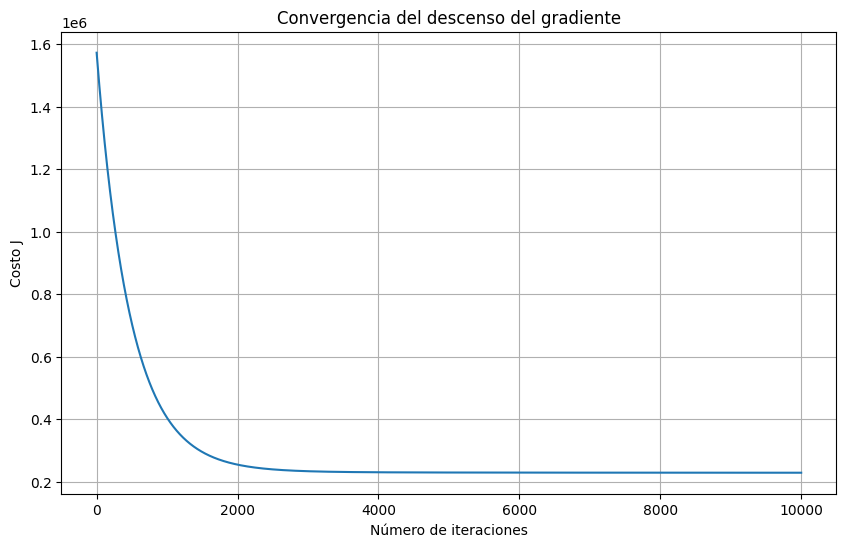

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    np.arange(len(J_history)),
    J_history
)

plt.xlabel("Número de iteraciones")
plt.ylabel("Costo J")
plt.title("Convergencia del descenso del gradiente")

plt.grid(True)
plt.show()

### Realización de Predicciones
Este bloque utiliza el vector `theta` aprendido para realizar predicciones sobre el conjunto de características `X`. Se calcula el producto punto entre `X` y `theta` para obtener los `y_pred` (precios predichos). Luego, se imprimen las primeras 10 predicciones comparándolas con los precios reales.

predicciones

In [36]:
y_pred = np.dot(X, theta)

print("Cantidad de predicciones:", len(y_pred))

print("\nPrecio real | Precio predicho")
print("-" * 40)

for i in range(10):
    print(
        f"{y[i]:10.2f} | {y_pred[i]:15.2f}"
    )

Cantidad de predicciones: 99491

Precio real | Precio predicho
----------------------------------------
   2195.00 |         2129.97
   1250.00 |         1812.49
   1395.00 |         1655.26
   1600.00 |         2318.44
    975.00 |          826.38
   1250.00 |         1148.33
   1600.00 |         1828.73
   1300.00 |         1810.48
    795.00 |          471.73
   2150.00 |         2720.37
